# 03 - Analisi degli errori: cosa accomuna gli ordini peggio previsti dalla baseline

**Domanda:** quali ordini hanno l'errore di previsione piu' alto sotto la **baseline ufficiale**
(`order_estimated_delivery_date`, la promessa di consegna dell'e-commerce)? Cosa hanno in comune?
E il modello finale della Sezione 9 di `01_eda.ipynb` (XGBoost asimmetrico tunato, `penalty=5`,
4.4% di anticipi sul test) risolve questi casi difficili o ci si scontra ancora?

Riusiamo lo stesso split temporale (80% piu' vecchio -> train, resto -> test) e la stessa
architettura/penalita' gia' validate in `01_eda.ipynb`, per confrontare mele con mele.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

from src import features

pd.options.display.float_format = '{:,.2f}'.format


## 1. Dati e split

Ricostruiamo `model_df` con le feature usate per il modello finale (Sezione 7-9 di `01_eda.ipynb`)
piu' alcune feature extra utili solo per l'esplorazione (non usate per allenare il modello, solo
per capire cosa distingue gli ordini difficili: carico venditore, dimensione ordine, calendario).

Split identico a quello usato in tutto `01_eda.ipynb`: ordiniamo per `purchase_date` e prendiamo
l'80% piu' vecchio come train, il resto come test.

In [2]:
top_features = ['distance_km_mean', 'total_freight', 'distance_km_max',
                 'customer_state', 'approval_hours', 'total_weight_g', 'main_category']
cat_features = ['customer_state', 'main_category']

extra_explore_cols = ['total_volume_cm3', 'seller_load_mean', 'seller_load_max',
                      'n_items', 'n_sellers', 'n_products', 'total_price',
                      'n_payments', 'max_installments', 'total_payment',
                      'purchase_month', 'purchase_dayofweek', 'purchase_is_weekend']

ft = features.build_feature_table()
keep_cols = (['order_id', 'purchase_date', 'delivery_days', 'estimated_days']
             + top_features + extra_explore_cols)
model_df = ft[keep_cols].copy()
for c in cat_features:
    model_df[c] = model_df[c].astype('category')

model_df = model_df.sort_values('purchase_date').reset_index(drop=True)
split = int(len(model_df) * 0.8)
train, test = model_df.iloc[:split], model_df.iloc[split:]

X_train, y_train = train[top_features], train['delivery_days']
X_test, y_test = test[top_features], test['delivery_days']
print(f'train: {len(train):,} righe | test: {len(test):,} righe')

train: 77,176 righe | test: 19,294 righe


## 2. Errore della baseline sul test set

Stessa convenzione usata in `01_eda.ipynb`: `errore = previsione - reale`.
Per la baseline, previsione = `estimated_days`. Un errore negativo significa che la baseline ha
promesso una consegna piu' rapida di quella reale (il caso che vogliamo penalizzare di piu').

Definiamo "errore alto" come il decile peggiore per **errore assoluto** (non solo gli anticipi):
ci interessano sia gli ordini dove la baseline e' troppo ottimista, sia quelli dove e' troppo
pessimista, per capire se sono le stesse tipologie di ordine o due popolazioni diverse.

In [3]:
test = test.copy()
test['baseline_err'] = test['estimated_days'] - test['delivery_days']
test['baseline_abs_err'] = test['baseline_err'].abs()

threshold = test['baseline_abs_err'].quantile(0.90)
high_err = test['baseline_abs_err'] >= threshold
print(f'Soglia (90esimo percentile errore assoluto baseline): {threshold:.1f} gg')
print(f'Ordini a errore alto: {high_err.sum():,} ({high_err.mean():.1%} del test)')

print()
print('MAE baseline:')
print(f"  gruppo errore alto : {test.loc[high_err, 'baseline_abs_err'].mean():.2f} gg")
print(f"  resto del test     : {test.loc[~high_err, 'baseline_abs_err'].mean():.2f} gg")
print()
print('Direzione dell\'errore nel gruppo alto (quota anticipi vs ritardi):')
print(f"  anticipata (err<0, promessa troppo ottimista): {(test.loc[high_err, 'baseline_err'] < 0).mean():.1%}")
print(f"  in ritardo (err>0, promessa troppo pessimista): {(test.loc[high_err, 'baseline_err'] > 0).mean():.1%}")

Soglia (90esimo percentile errore assoluto baseline): 25.5 gg
Ordini a errore alto: 1,930 (10.0% del test)

MAE baseline:
  gruppo errore alto : 31.38 gg
  resto del test     : 11.11 gg

Direzione dell'errore nel gruppo alto (quota anticipi vs ritardi):
  anticipata (err<0, promessa troppo ottimista): 1.6%
  in ritardo (err>0, promessa troppo pessimista): 98.4%


## 3. Feature numeriche: gruppo a errore alto vs resto

Confrontiamo media e mediana delle feature numeriche fra il gruppo a errore alto e il resto del
test set. Una differenza marcata segnala una feature legata alla difficolta' di previsione.

In [4]:
numeric_cols = ['distance_km_mean', 'distance_km_max', 'total_weight_g', 'total_volume_cm3',
                'total_freight', 'total_price', 'approval_hours',
                'seller_load_mean', 'seller_load_max', 'n_items', 'n_sellers', 'n_products']

comparison = pd.DataFrame({
    'media_errore_alto': test.loc[high_err, numeric_cols].mean(),
    'media_resto': test.loc[~high_err, numeric_cols].mean(),
})
comparison['rapporto'] = comparison['media_errore_alto'] / comparison['media_resto']
comparison.sort_values('rapporto', ascending=False)

,media_errore_alto,media_resto,rapporto
distance_km_max,836.76,542.42,1.54
distance_km_mean,830.27,541.10,1.53
total_freight,31.02,24.14,1.28
total_price,171.54,134.91,1.27
total_weight_g,"2,333.19","2,050.89",1.14
total_volume_cm3,"16,253.30","14,672.73",1.11
n_items,1.20,1.13,1.06
n_products,1.08,1.03,1.05
n_sellers,1.05,1.01,1.04
seller_load_max,22.74,25.38,0.90


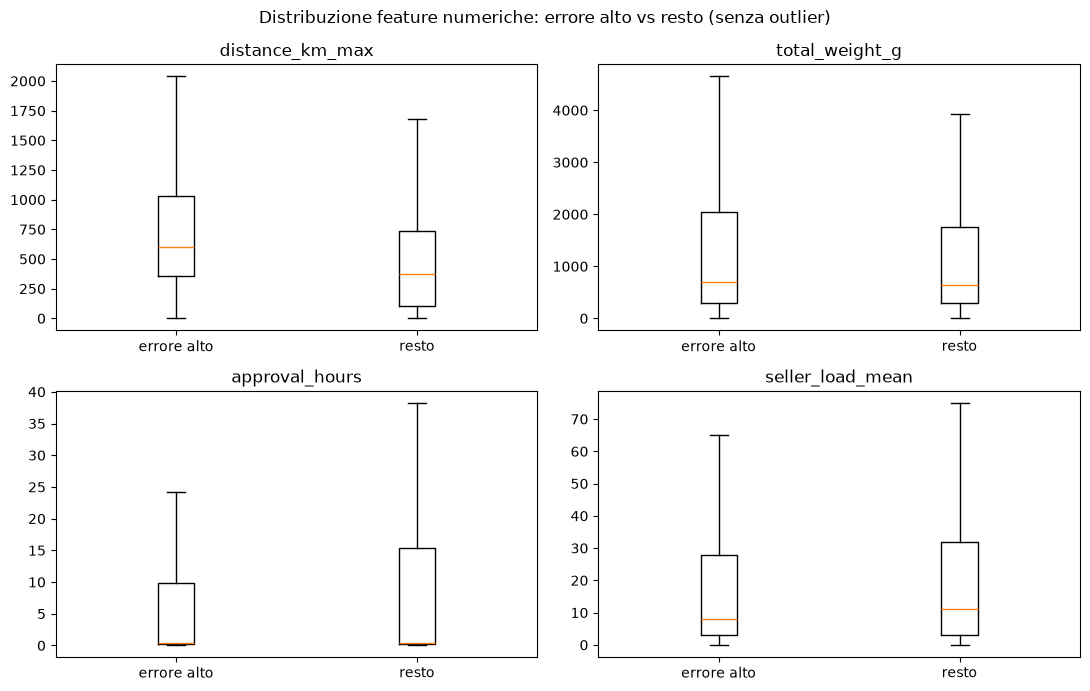

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
plot_cols = ['distance_km_max', 'total_weight_g', 'approval_hours', 'seller_load_mean']
labels = ['errore alto', 'resto']

for ax, col in zip(axes.ravel(), plot_cols):
    data = [test.loc[high_err, col].dropna(), test.loc[~high_err, col].dropna()]
    ax.boxplot(data, showfliers=False)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels)
    ax.set_title(col)

fig.suptitle('Distribuzione feature numeriche: errore alto vs resto (senza outlier)')
fig.tight_layout()
plt.show()

## 4. Feature categoriche e calendario: gruppo a errore alto vs resto

Guardiamo se il gruppo a errore alto e' sovra-rappresentato in certe categorie prodotto, stati
cliente, o momenti dell'anno/settimana rispetto alla loro frequenza nel resto del test set.

In [6]:
def overrepresentation(col, top_n=10):
    high_freq = test.loc[high_err, col].value_counts(normalize=True)
    rest_freq = test.loc[~high_err, col].value_counts(normalize=True)
    out = pd.DataFrame({'quota_errore_alto': high_freq, 'quota_resto': rest_freq}).fillna(0.0)
    out['rapporto'] = out['quota_errore_alto'] / out['quota_resto'].replace(0, np.nan)
    return out.sort_values('quota_errore_alto', ascending=False).head(top_n)

print('--- main_category ---')
display(overrepresentation('main_category'))
print('--- customer_state ---')
display(overrepresentation('customer_state'))

--- main_category ---


,quota_errore_alto,quota_resto,rapporto
main_category,,,
health_beauty,0.12,0.12,0.97
bed_bath_table,0.09,0.09,1.00
computers_accessories,0.08,0.06,1.49
housewares,0.08,0.08,1.05
watches_gifts,0.07,0.07,0.94
sports_leisure,0.07,0.07,1.01
furniture_decor,0.06,0.05,1.10
auto,0.04,0.05,0.78
baby,0.04,0.03,1.15


--- customer_state ---


,quota_errore_alto,quota_resto,rapporto
customer_state,,,
RJ,0.30,0.09,3.23
SP,0.21,0.49,0.43
MG,0.11,0.11,1.03
RS,0.07,0.05,1.63
PR,0.04,0.05,0.86
BA,0.04,0.03,1.11
PE,0.03,0.02,2.06
SC,0.03,0.03,0.91
PA,0.02,0.01,2.36


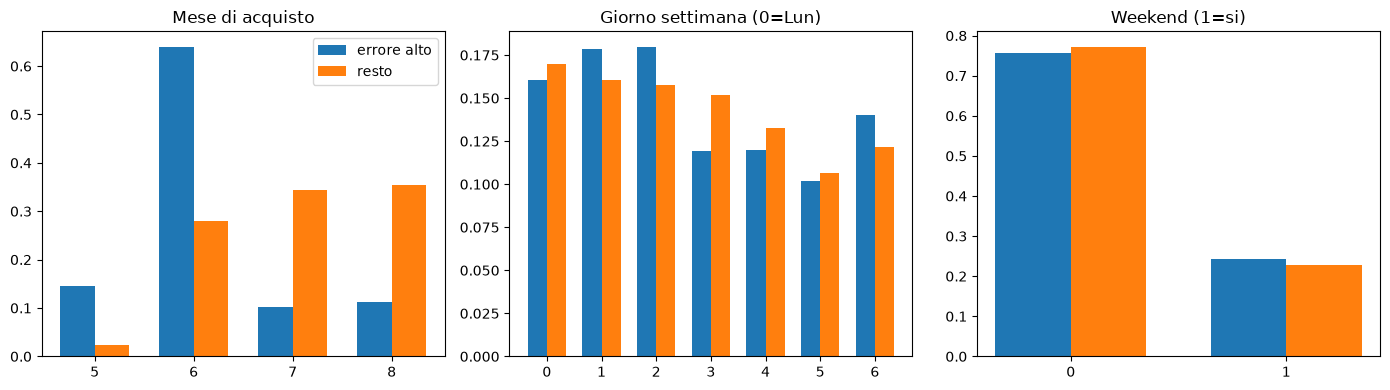

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in zip(
    axes,
    ['purchase_month', 'purchase_dayofweek', 'purchase_is_weekend'],
    ['Mese di acquisto', 'Giorno settimana (0=Lun)', 'Weekend (1=si)'],
):
    high_freq = test.loc[high_err, col].value_counts(normalize=True).sort_index()
    rest_freq = test.loc[~high_err, col].value_counts(normalize=True).sort_index()
    idx = sorted(set(high_freq.index) | set(rest_freq.index))
    width = 0.35
    x = np.arange(len(idx))
    ax.bar(x - width / 2, [high_freq.get(i, 0) for i in idx], width, label='errore alto')
    ax.bar(x + width / 2, [rest_freq.get(i, 0) for i in idx], width, label='resto')
    ax.set_xticks(x)
    ax.set_xticklabels(idx)
    ax.set_title(title)

axes[0].legend()
fig.tight_layout()
plt.show()

## 5. Sintesi: cosa accomuna gli ordini a errore alto (baseline)

Il decile peggiore per errore assoluto della baseline (soglia 25.5gg, 1.930 ordini) e':

- **Quasi tutto "ritardo", non "anticipo":** 98.4% degli ordini a errore alto sono casi in cui la
  baseline ha promesso una consegna piu' rapida di quella reale (solo 1.6% e' l'inverso). La
  baseline sottostima sistematicamente i tempi quando la logistica e' piu' complessa, non li
  sovrastima.
- **Guidato soprattutto dalla distanza:** `distance_km_max` e `distance_km_mean` sono le feature
  con il rapporto piu' alto fra gruppo a errore alto e resto (~1.53-1.54x), seguite da
  `total_freight`/`total_price` (~1.27-1.28x, ordini piu' grandi/costosi tendono a percorrere
  distanze maggiori). Peso/volume hanno un effetto piu' debole (~1.1-1.14x).
- **Il carico del venditore NON e' un driver:** a differenza di quanto ci si potrebbe aspettare,
  `seller_load_mean`/`seller_load_max` e `approval_hours` sono leggermente **piu' bassi** nel
  gruppo a errore alto (rapporto 0.85-0.90x), quindi non spiegano la difficolta' della baseline.
- **La categoria prodotto non discrimina** (nessun rapporto sopra ~1.5x su `main_category`), ma
  **lo stato del cliente si'**: **RJ** e' sovra-rappresentato 3.2x (30% degli ordini a errore
  alto contro 9% nel resto), **PA** 2.4x e **PE** 2.1x. Questo va oltre quello che la sola
  distanza in linea d'aria spiega (SP, il piu' vicino agli hub dei venditori, e' invece
  sotto-rappresentato: 21% vs 49%) — suggerisce fattori logistici specifici di alcune rotte/aree,
  non solo la distanza euclidea.

## 6. Il modello finale (Sezione 9): stesso subset, se lo risolve

Riproduciamo l'architettura tunata e la penalita' finale (`penalty=5`, 4.4% anticipi sul test,
MAE 10.00gg) esattamente come in `01_eda.ipynb`, allenandola sullo stesso `fit` split (85% del
train) usato per il tuning, cosi' i numeri sono confrontabili con quelli gia' riportati.

In [8]:
def make_asymmetric_mse(penalty):
    def obj(y_true, y_pred):
        residual = y_pred - y_true
        weight = np.where(residual < 0, penalty, 1.0)
        return 2 * weight * residual, 2 * weight
    return obj

best_arch = dict(subsample=0.7, n_estimators=300, min_child_weight=3, max_depth=5,
                  learning_rate=0.013707256063767185, colsample_bytree=0.6)

fit_split = int(len(train) * 0.85)
fit_df = train.iloc[:fit_split]
X_fit, y_fit = fit_df[top_features], fit_df['delivery_days']

tuned_model = XGBRegressor(objective=make_asymmetric_mse(5.0), enable_categorical=True,
                            tree_method='hist', random_state=42, **best_arch)
tuned_model.fit(X_fit, y_fit)

test['tuned_pred'] = tuned_model.predict(X_test)
test['tuned_err'] = test['tuned_pred'] - test['delivery_days']
test['tuned_abs_err'] = test['tuned_err'].abs()

def summarize(name, err):
    mae = err.abs().mean()
    early_share = (err < 0).mean()
    print(f'{name:35s} MAE: {mae:5.2f} gg   quota previsioni anticipate: {early_share:5.1%}')

print('--- Intero test set ---')
summarize('Baseline', test['baseline_err'])
summarize('Modello finale (penalty=5)', test['tuned_err'])

--- Intero test set ---
Baseline                            MAE: 13.13 gg   quota previsioni anticipate:  5.3%
Modello finale (penalty=5)          MAE: 10.00 gg   quota previsioni anticipate:  4.4%


## 7. Confronto sul subset difficile

Il decile a errore alto e' stato individuato **solo guardando la baseline**. Ora controlliamo:
il modello finale fa meglio anche su questi ordini specifici, o eredita la stessa difficolta'?
Per contrasto, guardiamo anche il resto del test set.

In [9]:
summary_rows = []
for label, mask in [('errore alto (baseline)', high_err), ('resto del test', ~high_err)]:
    summary_rows.append({
        'gruppo': label,
        'n_ordini': int(mask.sum()),
        'MAE_baseline': test.loc[mask, 'baseline_abs_err'].mean(),
        'anticipi_baseline': (test.loc[mask, 'baseline_err'] < 0).mean() * 100,
        'MAE_modello_finale': test.loc[mask, 'tuned_abs_err'].mean(),
        'anticipi_modello_finale': (test.loc[mask, 'tuned_err'] < 0).mean() * 100,
    })

summary = pd.DataFrame(summary_rows).set_index('gruppo')
summary.round(2)

,n_ordini,MAE_baseline,anticipi_baseline,MAE_modello_finale,anticipi_modello_finale
gruppo,,,,,
errore alto (baseline),1930,31.38,1.55,13.15,2.49
resto del test,17364,11.11,5.71,9.64,4.63


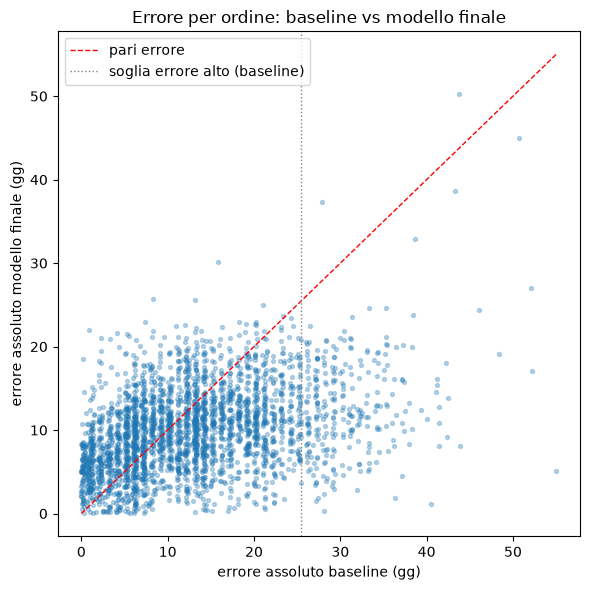

Correlazione errore assoluto baseline vs modello finale: 0.38


In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
sample = test.sample(min(3000, len(test)), random_state=42)
ax.scatter(sample['baseline_abs_err'], sample['tuned_abs_err'], s=8, alpha=0.3)
lim = max(sample['baseline_abs_err'].max(), sample['tuned_abs_err'].max())
ax.plot([0, lim], [0, lim], color='red', linestyle='--', linewidth=1, label='pari errore')
ax.axvline(threshold, color='gray', linestyle=':', linewidth=1, label='soglia errore alto (baseline)')
ax.set_xlabel('errore assoluto baseline (gg)')
ax.set_ylabel('errore assoluto modello finale (gg)')
ax.set_title('Errore per ordine: baseline vs modello finale')
ax.legend()
fig.tight_layout()
plt.show()

corr = test['baseline_abs_err'].corr(test['tuned_abs_err'])
print(f'Correlazione errore assoluto baseline vs modello finale: {corr:.2f}')

## 8. Conclusioni

- Il decile di ordini peggio previsti dalla **baseline ufficiale** e' guidato soprattutto dalla
  **distanza venditore-cliente** (media e max ~1.5x piu' alta) e, in modo piu' sorprendente, da
  uno **stato cliente specifico (RJ, sovra-rappresentato 3.2x)** che va oltre cio' che la
  distanza da sola spiegherebbe. Il carico del venditore *non* e' un fattore: e' anzi
  leggermente piu' basso nel gruppo difficile. In quasi tutti questi casi (98.4%) la baseline
  **sottostima** i giorni di consegna, promettendo una data troppo ottimista.
- Il **modello finale** (XGBoost asimmetrico tunato, `penalty=5`) migliora **molto di piu'** il
  gruppo che la baseline sbagliava peggio: MAE 31.38 -> 13.15gg (-58%, -18.2gg) contro
  11.11 -> 9.64gg (-13%, -1.5gg) sul resto del test. Il modello corregge quindi in modo
  sproporzionato proprio i casi piu' critici per il business (i grandi ritardi rispetto alla
  promessa), non solo la media generale.
- Resta pero' un compromesso: sul gruppo difficile la quota di previsioni anticipate **sale**
  leggermente rispetto alla baseline (1.6% -> 2.5%), mentre sul resto del test **scende**
  (5.7% -> 4.6%). In valore assoluto entrambe restano sotto la soglia del 5% fissata a livello
  di intero test set (4.4%), ma il segmento a lunga distanza / RJ-PA-PE e' quello dove il
  margine di sicurezza si consuma di piu': la correlazione moderata (0.38) fra errore-baseline
  ed errore-modello conferma che gli ordini logisticamente complessi restano relativamente piu'
  difficili anche per il modello, pur con un errore assoluto molto ridotto.
- **Implicazione pratica:** vale la pena monitorare separatamente gli ordini a lunga distanza e
  verso RJ/PA/PE in produzione — e' il segmento dove il modello guadagna di piu' rispetto alla
  baseline, ma anche quello che assorbe la maggior parte del rischio residuo di anticipo. Un
  margine di sicurezza differenziato per questo segmento (invece che uniforme su tutti gli
  ordini) potrebbe comprimere ulteriormente la quota di anticipi senza gonfiare il MAE medio
  sugli ordini gia' facili.